<a href="https://colab.research.google.com/github/InowaR/colab/blob/main/generate_points_in_polygon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Генерация точек...
Сгенерировано точек: 106
Расстояние между точками: 0.25
Отступ от периметра: 0.3


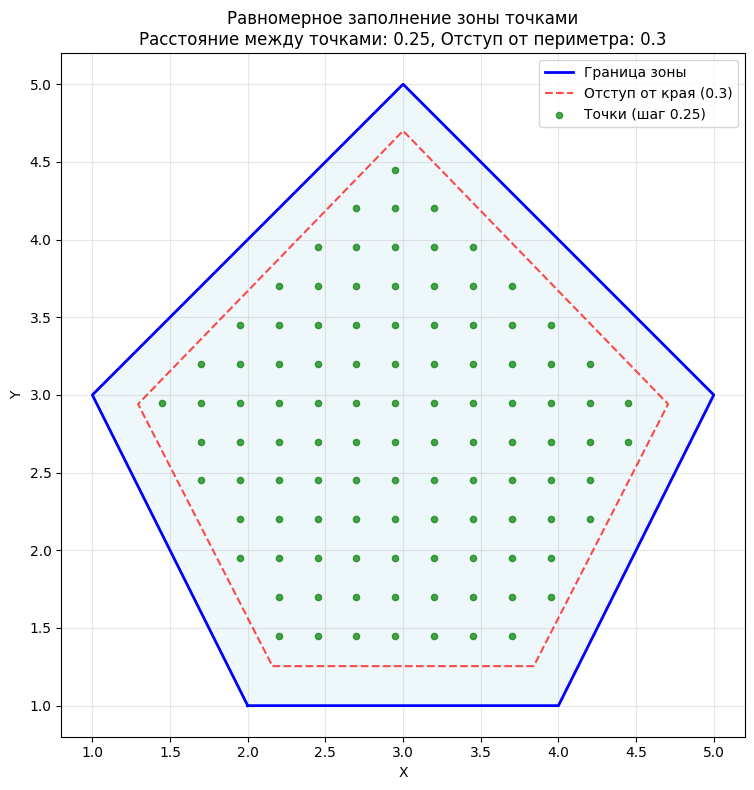


Статистика:
X: от 1.45 до 4.45
Y: от 1.45 до 4.45


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def point_in_polygon(point, polygon_vertices):
    """
    Проверяет, находится ли точка внутри многоугольника (алгоритм лучевого пересечения)
    """
    x, y = point
    n = len(polygon_vertices)
    inside = False

    p1x, p1y = polygon_vertices[0]
    for i in range(n + 1):
        p2x, p2y = polygon_vertices[i % n]
        if y > min(p1y, p2y):
            if y <= max(p1y, p2y):
                if x <= max(p1x, p2x):
                    if p1y != p2y:
                        xinters = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
                    if p1x == p2x or x <= xinters:
                        inside = not inside
        p1x, p1y = p2x, p2y

    return inside

def distance_to_segment(point, p1, p2):
    """
    Вычисляет минимальное расстояние от точки до отрезка
    """
    x, y = point
    x1, y1 = p1
    x2, y2 = p2

    # Вектор отрезка
    dx = x2 - x1
    dy = y2 - y1

    if dx == 0 and dy == 0:
        return np.sqrt((x - x1)**2 + (y - y1)**2)

    # Параметр ближайшей точки на отрезке
    t = ((x - x1) * dx + (y - y1) * dy) / (dx*dx + dy*dy)

    if t < 0:
        # Ближайшая точка - p1
        closest_x, closest_y = x1, y1
    elif t > 1:
        # Ближайшая точка - p2
        closest_x, closest_y = x2, y2
    else:
        # Ближайшая точка внутри отрезка
        closest_x = x1 + t * dx
        closest_y = y1 + t * dy

    return np.sqrt((x - closest_x)**2 + (y - closest_y)**2)

def distance_to_polygon(point, polygon_vertices):
    """
    Вычисляет минимальное расстояние от точки до периметра многоугольника
    """
    min_dist = float('inf')
    n = len(polygon_vertices)

    for i in range(n):
        p1 = polygon_vertices[i]
        p2 = polygon_vertices[(i + 1) % n]
        dist = distance_to_segment(point, p1, p2)
        if dist < min_dist:
            min_dist = dist

    return min_dist

def generate_points_in_polygon(polygon_vertices, point_spacing, margin_from_edge):
    """
    Генерирует равномерную сетку точек внутри многоугольника
    с учетом отступа от периметра и расстояния между точками

    Параметры:
    - polygon_vertices: список вершин многоугольника [(x1,y1), (x2,y2), ...]
    - point_spacing: расстояние между точками внутри зоны
    - margin_from_edge: минимальное расстояние от точки до периметра зоны
    """
    # Находим границы многоугольника
    vertices = np.array(polygon_vertices)
    min_x = np.min(vertices[:, 0])
    max_x = np.max(vertices[:, 0])
    min_y = np.min(vertices[:, 1])
    max_y = np.max(vertices[:, 1])

    # Расширяем границы с учетом отступа
    min_x -= margin_from_edge
    max_x += margin_from_edge
    min_y -= margin_from_edge
    max_y += margin_from_edge

    points = []

    # Создаем сетку с заданным шагом
    x_coords = np.arange(min_x, max_x + point_spacing, point_spacing)
    y_coords = np.arange(min_y, max_y + point_spacing, point_spacing)

    for x in x_coords:
        for y in y_coords:
            point = (x, y)

            # Проверяем, находится ли точка внутри многоугольника
            if point_in_polygon(point, polygon_vertices):
                # Проверяем расстояние до периметра
                dist_to_edge = distance_to_polygon(point, polygon_vertices)
                if dist_to_edge >= margin_from_edge:
                    points.append(point)

    return points

def visualize_points(polygon_vertices, points, margin_from_edge, point_spacing):
    """
    Визуализирует многоугольник и сгенерированные точки
    """
    fig, ax = plt.subplots(figsize=(10, 8))

    # Рисуем многоугольник
    polygon_closed = np.array(polygon_vertices + [polygon_vertices[0]])
    ax.plot(polygon_closed[:, 0], polygon_closed[:, 1], 'b-', linewidth=2, label='Граница зоны')
    ax.fill(polygon_closed[:, 0], polygon_closed[:, 1], alpha=0.2, color='lightblue')

    # Рисуем внутреннюю границу (отступ от периметра)
    # Для визуализации отступа создаем уменьшенный многоугольник
    inner_polygon = shrink_polygon(polygon_vertices, margin_from_edge)
    if inner_polygon:
        inner_closed = np.array(inner_polygon + [inner_polygon[0]])
        ax.plot(inner_closed[:, 0], inner_closed[:, 1], 'r--', linewidth=1.5,
                alpha=0.7, label=f'Отступ от края ({margin_from_edge})')

    # Рисуем точки
    if points:
        points_arr = np.array(points)
        ax.scatter(points_arr[:, 0], points_arr[:, 1], c='green', s=20,
                  alpha=0.7, label=f'Точки (шаг {point_spacing})')

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_title(f'Равномерное заполнение зоны точками\n'
                f'Расстояние между точками: {point_spacing}, '
                f'Отступ от периметра: {margin_from_edge}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

    plt.tight_layout()
    plt.show()

def shrink_polygon(polygon_vertices, distance):
    """
    Упрощенная версия уменьшения многоугольника для визуализации отступа
    (только для выпуклых многоугольников)
    """
    if len(polygon_vertices) < 3:
        return None

    vertices = np.array(polygon_vertices)
    center = np.mean(vertices, axis=0)

    # Для невыпуклых многоугольников эта эвристика может работать некорректно
    # Для точного уменьшения нужна более сложная логика
    shrunk_vertices = []

    for i in range(len(vertices)):
        # Вектор от центра к вершине
        vec = vertices[i] - center
        vec_norm = np.linalg.norm(vec)
        if vec_norm > distance:
            new_vec = vec * (1 - distance / vec_norm)
            shrunk_vertices.append(center + new_vec)
        else:
            return None

    # Проверяем, что после уменьшения многоугольник все еще существует
    if len(shrunk_vertices) >= 3:
        return shrunk_vertices
    return None

# Пример использования
def main():
    # Константы (меняйте здесь значения)
    POINT_SPACING = 0.25      # Расстояние между точками внутри зоны
    MARGIN_FROM_EDGE = 0.3    # Минимальное расстояние от точки до периметра зоны

    # Задаем произвольную фигуру с углами (пятиугольник)
    polygon = [
        (2, 1),
        (4, 1),
        (5, 3),
        (3, 5),
        (1, 3)
    ]

    # Генерируем точки
    print("Генерация точек...")
    points = generate_points_in_polygon(polygon, POINT_SPACING, MARGIN_FROM_EDGE)
    print(f"Сгенерировано точек: {len(points)}")
    print(f"Расстояние между точками: {POINT_SPACING}")
    print(f"Отступ от периметра: {MARGIN_FROM_EDGE}")

    # Визуализируем результат
    visualize_points(polygon, points, MARGIN_FROM_EDGE, POINT_SPACING)

    # Дополнительная статистика
    if points:
        points_arr = np.array(points)
        print(f"\nСтатистика:")
        print(f"X: от {np.min(points_arr[:, 0]):.2f} до {np.max(points_arr[:, 0]):.2f}")
        print(f"Y: от {np.min(points_arr[:, 1]):.2f} до {np.max(points_arr[:, 1]):.2f}")

# Пример с более сложной фигурой
def example_complex_shape():
    # Константы
    POINT_SPACING = 0.2
    MARGIN_FROM_EDGE = 0.25

    # Шестиугольник
    polygon = [
        (3, 0),
        (6, 1.5),
        (6, 4.5),
        (3, 6),
        (0, 4.5),
        (0, 1.5)
    ]

    points = generate_points_in_polygon(polygon, POINT_SPACING, MARGIN_FROM_EDGE)
    visualize_points(polygon, points, MARGIN_FROM_EDGE, POINT_SPACING)
    print(f"Сгенерировано точек: {len(points)}")

if __name__ == "__main__":
    main()
    # Раскомментируйте для теста с другой фигурой:
    # example_complex_shape()

Генерация точек...
Сгенерировано точек: 106
Создание зигзагообразного пути...


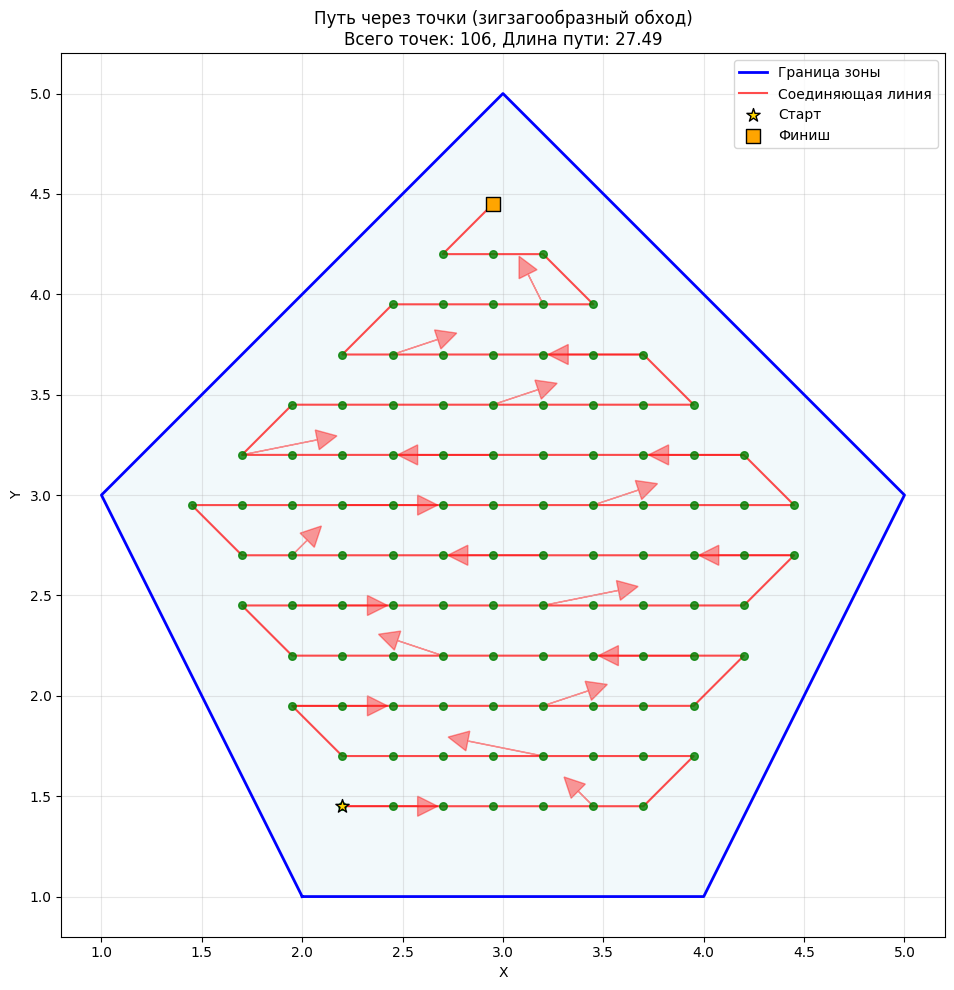


Статистика пути:
Длина пути: 27.49
Количество точек: 106
Среднее расстояние между точками: 0.259


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def point_in_polygon(point, polygon_vertices):
    """
    Проверяет, находится ли точка внутри многоугольника (алгоритм лучевого пересечения)
    """
    x, y = point
    n = len(polygon_vertices)
    inside = False

    p1x, p1y = polygon_vertices[0]
    for i in range(n + 1):
        p2x, p2y = polygon_vertices[i % n]
        if y > min(p1y, p2y):
            if y <= max(p1y, p2y):
                if x <= max(p1x, p2x):
                    if p1y != p2y:
                        xinters = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
                    if p1x == p2x or x <= xinters:
                        inside = not inside
        p1x, p1y = p2x, p2y

    return inside

def distance_to_segment(point, p1, p2):
    """
    Вычисляет минимальное расстояние от точки до отрезка
    """
    x, y = point
    x1, y1 = p1
    x2, y2 = p2

    dx = x2 - x1
    dy = y2 - y1

    if dx == 0 and dy == 0:
        return np.sqrt((x - x1)**2 + (y - y1)**2)

    t = ((x - x1) * dx + (y - y1) * dy) / (dx*dx + dy*dy)

    if t < 0:
        closest_x, closest_y = x1, y1
    elif t > 1:
        closest_x, closest_y = x2, y2
    else:
        closest_x = x1 + t * dx
        closest_y = y1 + t * dy

    return np.sqrt((x - closest_x)**2 + (y - closest_y)**2)

def distance_to_polygon(point, polygon_vertices):
    """
    Вычисляет минимальное расстояние от точки до периметра многоугольника
    """
    min_dist = float('inf')
    n = len(polygon_vertices)

    for i in range(n):
        p1 = polygon_vertices[i]
        p2 = polygon_vertices[(i + 1) % n]
        dist = distance_to_segment(point, p1, p2)
        if dist < min_dist:
            min_dist = dist

    return min_dist

def generate_points_in_polygon(polygon_vertices, point_spacing, margin_from_edge):
    """
    Генерирует равномерную сетку точек внутри многоугольника
    """
    vertices = np.array(polygon_vertices)
    min_x = np.min(vertices[:, 0])
    max_x = np.max(vertices[:, 0])
    min_y = np.min(vertices[:, 1])
    max_y = np.max(vertices[:, 1])

    min_x -= margin_from_edge
    max_x += margin_from_edge
    min_y -= margin_from_edge
    max_y += margin_from_edge

    points = []

    x_coords = np.arange(min_x, max_x + point_spacing, point_spacing)
    y_coords = np.arange(min_y, max_y + point_spacing, point_spacing)

    for x in x_coords:
        for y in y_coords:
            point = (x, y)

            if point_in_polygon(point, polygon_vertices):
                dist_to_edge = distance_to_polygon(point, polygon_vertices)
                if dist_to_edge >= margin_from_edge:
                    points.append(point)

    return points

def sort_points_for_path(points):
    """
    Сортирует точки для создания непрерывного пути (алгоритм ближайшего соседа)
    """
    if not points:
        return []

    points = list(points)
    sorted_points = [points[0]]
    points.pop(0)

    while points:
        # Находим ближайшую точку к последней в пути
        last_point = sorted_points[-1]
        distances = [np.linalg.norm(np.array(p) - np.array(last_point)) for p in points]
        nearest_idx = np.argmin(distances)
        sorted_points.append(points[nearest_idx])
        points.pop(nearest_idx)

    return sorted_points

def sort_points_by_hilbert(points, num_iterations=5):
    """
    Сортирует точки с использованием кривой Гильберта для лучшей пространственной организации
    """
    if not points:
        return []

    points = np.array(points)

    # Находим границы
    min_x, min_y = np.min(points, axis=0)
    max_x, max_y = np.max(points, axis=0)

    # Нормализуем координаты в диапазон [0, 1]
    normalized = (points - [min_x, min_y]) / [max_x - min_x, max_y - min_y]

    def hilbert_code(x, y, iter):
        """Вычисляет код Гильберта для точки"""
        code = 0
        for i in range(iter - 1, -1, -1):
            xi = (x >> i) & 1
            yi = (y >> i) & 1

            if xi == 0 and yi == 0:
                code = (code << 2) | 0
            elif xi == 0 and yi == 1:
                code = (code << 2) | 3
            elif xi == 1 and yi == 0:
                code = (code << 2) | 1
            else:
                code = (code << 2) | 2
        return code

    # Дискретизируем координаты
    grid_size = 2 ** num_iterations
    x_disc = np.floor(normalized[:, 0] * grid_size).astype(int)
    y_disc = np.floor(normalized[:, 1] * grid_size).astype(int)

    # Вычисляем коды Гильберта
    codes = [hilbert_code(x_disc[i], y_disc[i], num_iterations) for i in range(len(points))]

    # Сортируем по кодам
    sorted_indices = np.argsort(codes)

    return [tuple(points[i]) for i in sorted_indices]

def sort_points_by_angle(points, center=None):
    """
    Сортирует точки по углу относительно центра (для спирального обхода)
    """
    if not points:
        return []

    points = np.array(points)

    if center is None:
        center = np.mean(points, axis=0)

    # Вычисляем углы относительно центра
    angles = np.arctan2(points[:, 1] - center[1], points[:, 0] - center[0])

    # Сортируем по углу
    sorted_indices = np.argsort(angles)

    return [tuple(points[i]) for i in sorted_indices]

def create_zigzag_path(points, direction='horizontal'):
    """
    Создает зигзагообразный путь через точки
    """
    if not points:
        return []

    points = np.array(points)

    if direction == 'horizontal':
        # Сортируем по y, затем по x (зигзаг)
        unique_y = np.unique(points[:, 1])
        sorted_points = []

        for i, y in enumerate(sorted(unique_y)):
            y_points = points[points[:, 1] == y]
            if i % 2 == 0:
                # Четные строки - слева направо
                y_points_sorted = y_points[y_points[:, 0].argsort()]
            else:
                # Нечетные строки - справа налево
                y_points_sorted = y_points[y_points[:, 0].argsort()[::-1]]
            sorted_points.extend(y_points_sorted)
    else:
        # Сортируем по x, затем по y (вертикальный зигзаг)
        unique_x = np.unique(points[:, 0])
        sorted_points = []

        for i, x in enumerate(sorted(unique_x)):
            x_points = points[points[:, 0] == x]
            if i % 2 == 0:
                x_points_sorted = x_points[x_points[:, 1].argsort()]
            else:
                x_points_sorted = x_points[x_points[:, 1].argsort()[::-1]]
            sorted_points.extend(x_points_sorted)

    return [tuple(p) for p in sorted_points]

def visualize_with_path(polygon_vertices, points, sorted_points, title="Путь через точки"):
    """
    Визуализирует многоугольник и путь, соединяющий все точки
    """
    fig, ax = plt.subplots(figsize=(12, 10))

    # Рисуем многоугольник
    polygon_closed = np.array(polygon_vertices + [polygon_vertices[0]])
    ax.fill(polygon_closed[:, 0], polygon_closed[:, 1], alpha=0.15, color='lightblue')
    ax.plot(polygon_closed[:, 0], polygon_closed[:, 1], 'b-', linewidth=2, label='Граница зоны')

    # Рисуем путь, соединяющий точки
    if sorted_points:
        path_array = np.array(sorted_points)
        ax.plot(path_array[:, 0], path_array[:, 1], 'r-', linewidth=1.5, alpha=0.7,
                label='Соединяющая линия')

        # Отмечаем точки
        ax.scatter(path_array[:, 0], path_array[:, 1], c='green', s=30,
                  alpha=0.8, zorder=5)

        # Отмечаем начальную и конечную точки
        ax.scatter(path_array[0, 0], path_array[0, 1], c='gold', s=100,
                  marker='*', zorder=6, label='Старт', edgecolors='black', linewidth=1)
        ax.scatter(path_array[-1, 0], path_array[-1, 1], c='orange', s=100,
                  marker='s', zorder=6, label='Финиш', edgecolors='black', linewidth=1)

        # Добавляем стрелки для указания направления (каждые N точек)
        arrow_step = max(1, len(sorted_points) // 20)
        for i in range(0, len(sorted_points) - arrow_step, arrow_step):
            if i + arrow_step < len(sorted_points):
                dx = path_array[i + arrow_step, 0] - path_array[i, 0]
                dy = path_array[i + arrow_step, 1] - path_array[i, 1]
                dist = np.sqrt(dx*dx + dy*dy)
                if dist > 0:
                    ax.arrow(path_array[i, 0], path_array[i, 1],
                            dx * 0.3, dy * 0.3,
                            head_width=0.1, head_length=0.1,
                            fc='red', ec='red', alpha=0.4)

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

    # Добавляем информацию о пути
    if sorted_points:
        total_length = sum(np.linalg.norm(np.array(sorted_points[i+1]) - np.array(sorted_points[i]))
                          for i in range(len(sorted_points)-1))
        ax.set_title(f'{title}\n'
                    f'Всего точек: {len(sorted_points)}, '
                    f'Длина пути: {total_length:.2f}')
    else:
        ax.set_title(title)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')

    plt.tight_layout()
    plt.show()

# Основная функция
def main():
    # Константы
    POINT_SPACING = 0.25      # Расстояние между точками внутри зоны
    MARGIN_FROM_EDGE = 0.3    # Минимальное расстояние от точки до периметра зоны
    SORT_METHOD = 'zigzag'     # Метод сортировки: 'nearest', 'hilbert', 'angle', 'zigzag'

    # Задаем произвольную фигуру с углами (пятиугольник)
    polygon = [
        (2, 1),
        (4, 1),
        (5, 3),
        (3, 5),
        (1, 3)
    ]

    # Генерируем точки
    print("Генерация точек...")
    points = generate_points_in_polygon(polygon, POINT_SPACING, MARGIN_FROM_EDGE)
    print(f"Сгенерировано точек: {len(points)}")

    # Сортируем точки для создания непрерывного пути
    if SORT_METHOD == 'nearest':
        print("Сортировка методом ближайшего соседа...")
        sorted_points = sort_points_for_path(points)
        title = "Путь через точки (метод ближайшего соседа)"
    elif SORT_METHOD == 'hilbert':
        print("Сортировка кривой Гильберта...")
        sorted_points = sort_points_by_hilbert(points)
        title = "Путь через точки (кривая Гильберта)"
    elif SORT_METHOD == 'angle':
        print("Сортировка по углу...")
        sorted_points = sort_points_by_angle(points)
        title = "Путь через точки (спиральный обход)"
    elif SORT_METHOD == 'zigzag':
        print("Создание зигзагообразного пути...")
        sorted_points = create_zigzag_path(points, direction='horizontal')
        title = "Путь через точки (зигзагообразный обход)"
    else:
        sorted_points = sort_points_for_path(points)
        title = "Путь через точки"

    # Визуализируем результат
    visualize_with_path(polygon, points, sorted_points, title)

    # Выводим статистику
    if sorted_points:
        total_length = sum(np.linalg.norm(np.array(sorted_points[i+1]) - np.array(sorted_points[i]))
                          for i in range(len(sorted_points)-1))
        print(f"\nСтатистика пути:")
        print(f"Длина пути: {total_length:.2f}")
        print(f"Количество точек: {len(sorted_points)}")
        print(f"Среднее расстояние между точками: {total_length/len(sorted_points):.3f}")

# Пример с более сложной фигурой
def example_complex_shape():
    POINT_SPACING = 0.2
    MARGIN_FROM_EDGE = 0.25

    # Шестиугольник
    polygon = [
        (3, 0),
        (6, 1.5),
        (6, 4.5),
        (3, 6),
        (0, 4.5),
        (0, 1.5)
    ]

    points = generate_points_in_polygon(polygon, POINT_SPACING, MARGIN_FROM_EDGE)
    print(f"Сгенерировано точек: {len(points)}")

    # Используем зигзагообразный путь для сетки
    sorted_points = create_zigzag_path(points, direction='horizontal')
    visualize_with_path(polygon, points, sorted_points, "Путь через точки (зигзаг) - шестиугольник")

if __name__ == "__main__":
    main()
    # Раскомментируйте для теста с другой фигурой:
    # example_complex_shape()